In [1]:
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

In [2]:
def aicc_weights_from_model_info(path: str) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    rows = []
    for episode_data in data["bandwidth_optimization"]:
        bandwidth_raw = episode_data.get("bandwidth")
        if isinstance(bandwidth_raw, str):
            bandwidth_list = json.loads(bandwidth_raw)
        elif bandwidth_raw is None:
            bandwidth_list = []
        else:
            bandwidth_list = list(bandwidth_raw)

        rows.append({
            "episode": episode_data["episode"],
            "AICc": float(episode_data["reward"]),
            "bandwidth": bandwidth_list,
        })

    df = pd.DataFrame(rows).sort_values("episode").reset_index(drop=True)
    aicc_min = df["AICc"].min()
    df["Delta"] = df["AICc"] - aicc_min
    # Akaike weights
    lik = (df["Delta"] * -0.5).apply(math.exp)
    df["weight"] = lik / lik.sum()
    return df[["episode", "AICc", "Delta", "weight", "bandwidth"]]

def plot(b, sub_title=['', ''], size=40, vmin=None, vmax=None):
    k = len(b)
    fig, axs = plt.subplots(1, k, figsize=(6*k, 4))
    if k == 1:
        axs = [axs]
    for i in range(k):
        ax_img = axs[i].imshow(b[i].reshape(size, size),
                               cmap=colormaps['viridis'], vmin=vmin, vmax=vmax)
        axs[i].set_title(sub_title[i], fontsize=16)
        fig.colorbar(ax_img, ax=axs[i])
        axs[i].set_xticks(np.arange(-0.5, size, 5))
        axs[i].set_yticks(np.arange(-0.5, size, 5))
        axs[i].set_xticklabels([])
        axs[i].set_yticklabels([])
        axs[i].tick_params(axis='x', colors=(0, 0, 0, 0))
        axs[i].tick_params(axis='y', colors=(0, 0, 0, 0))
    plt.show()

# Compute the global Moran's I using rook contiguity on the grid.
def global_morans_i(grid: np.ndarray) -> float:
    arr = np.asarray(grid, dtype=float)
    mask = ~np.isnan(arr)
    n = mask.sum()
    if n <= 1:
        return np.nan
    mean = arr[mask].mean()
    centered = arr - mean
    centered[~mask] = 0.0
    denom = np.sum(centered[mask] ** 2)
    if denom == 0.0:
        return np.nan
    pair_sum = 0.0
    num_pairs = 0
    # horizontal neighbors
    horiz_mask = mask[:, :-1] & mask[:, 1:]
    if np.any(horiz_mask):
        pair_sum += np.sum(centered[:, :-1][horiz_mask] * centered[:, 1:][horiz_mask])
        num_pairs += np.sum(horiz_mask)
    # vertical neighbors
    vert_mask = mask[:-1, :] & mask[1:, :]
    if np.any(vert_mask):
        pair_sum += np.sum(centered[:-1, :][vert_mask] * centered[1:, :][vert_mask])
        num_pairs += np.sum(vert_mask)
    if num_pairs == 0:
        return np.nan
    numerator = 2.0 * pair_sum
    s0 = 2.0 * num_pairs
    return (n / s0) * (numerator / denom)

# Render the bandwidth grids as 3D surfaces for extra depth cues.
def plot_surface_3d(b, sub_title=['', ''], size=40, vmin=None, vmax=None):
    k = len(b)
    fig = plt.figure(figsize=(6*k, 5))
    x = np.arange(size)
    y = np.arange(size)
    X, Y = np.meshgrid(x, y)
    cmap = colormaps['viridis']
    norm = Normalize(vmin=vmin, vmax=vmax)
    for i in range(k):
        ax = fig.add_subplot(1, k, i + 1, projection='3d')
        surf = ax.plot_surface(X, Y, b[i], cmap=cmap, norm=norm,
                               linewidth=0, antialiased=True)
        ax.set_title(sub_title[i], fontsize=14)
        ax.set_xlabel("X Index")
        ax.set_ylabel("Y Index")
        ax.set_zlabel("Bandwidth")
        ax.view_init(elev=35, azim=-135)
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    fig.colorbar(sm, ax=fig.axes, shrink=0.6, pad=0.1, label="Bandwidth")
    plt.tight_layout()
    plt.show()


Load the model info and sort table by aicc weight (descending)

In [3]:
aicc_weights = aicc_weights_from_model_info(r"./logs/lgwr-2025-10-16-14-19-29-log/model_info.json")
sorted_df = aicc_weights.sort_values('weight', ascending=False).reset_index(drop=True)

Calculate the cummulation weight, and find the episodes resulting in exceeding .95 threshold.

In [4]:
sorted_df['cumulation'] = sorted_df['weight'].cumsum()
num_rows = (sorted_df['cumulation'] > 0.95).argmax() + 1
result_df = sorted_df.iloc[:num_rows]
print(result_df)

   episode         AICc  Delta    weight  \
0      709  5496.555866    0.0  0.999971   

                                           bandwidth  cumulation  
0  [243, 1450, 731, 1453, 332, 85, 1251, 1321, 34...    0.999971  


In [5]:
bandwidth_array = np.array(result_df["bandwidth"].tolist())
lower = bandwidth_array.min(axis=0)
upper = bandwidth_array.max(axis=0)
df_bw = pd.DataFrame({
    "lower": [lower.tolist()], 
    "upper": [upper.tolist()],
    "lowest_aicc_bandwidth": [bandwidth_array[0].tolist()]
})

Prepare data for plotting

In [6]:
lower_list = df_bw["lower"].to_list()
upper_list = df_bw["upper"].to_list()
lowest_aicc_bandwidth_list = df_bw["lowest_aicc_bandwidth"].to_list()

size = 40
lower_2d = np.array(lower_list).reshape(size, size)
upper_2d = np.array(upper_list).reshape(size, size)
lowest_aicc_bandwidth_2d = np.array(lowest_aicc_bandwidth_list).reshape(size, size)

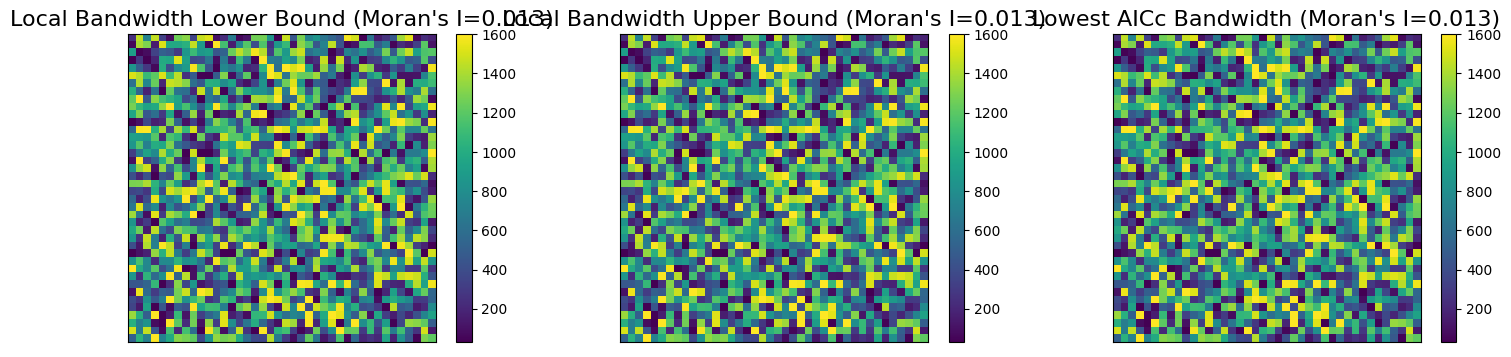

In [7]:
# Set global vmin and vmax for consistent coloring
all_data = [lower_2d, upper_2d, lowest_aicc_bandwidth_2d]
global_vmin = min(np.nanmin(arr) for arr in all_data)
global_vmax = max(np.nanmax(arr) for arr in all_data)
morans_values = [global_morans_i(arr) for arr in all_data]

plot([lower_2d, upper_2d, lowest_aicc_bandwidth_2d],
    sub_title=[f"Local Bandwidth Lower Bound (Moran's I={morans_values[0]:.3f})",
               f"Local Bandwidth Upper Bound (Moran's I={morans_values[1]:.3f})",
               f"Lowest AICc Bandwidth (Moran's I={morans_values[2]:.3f})"],
    size=size, vmin=global_vmin, vmax=global_vmax)

C:\Users\jim60\AppData\Local\Temp\ipykernel_6352\591008472.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


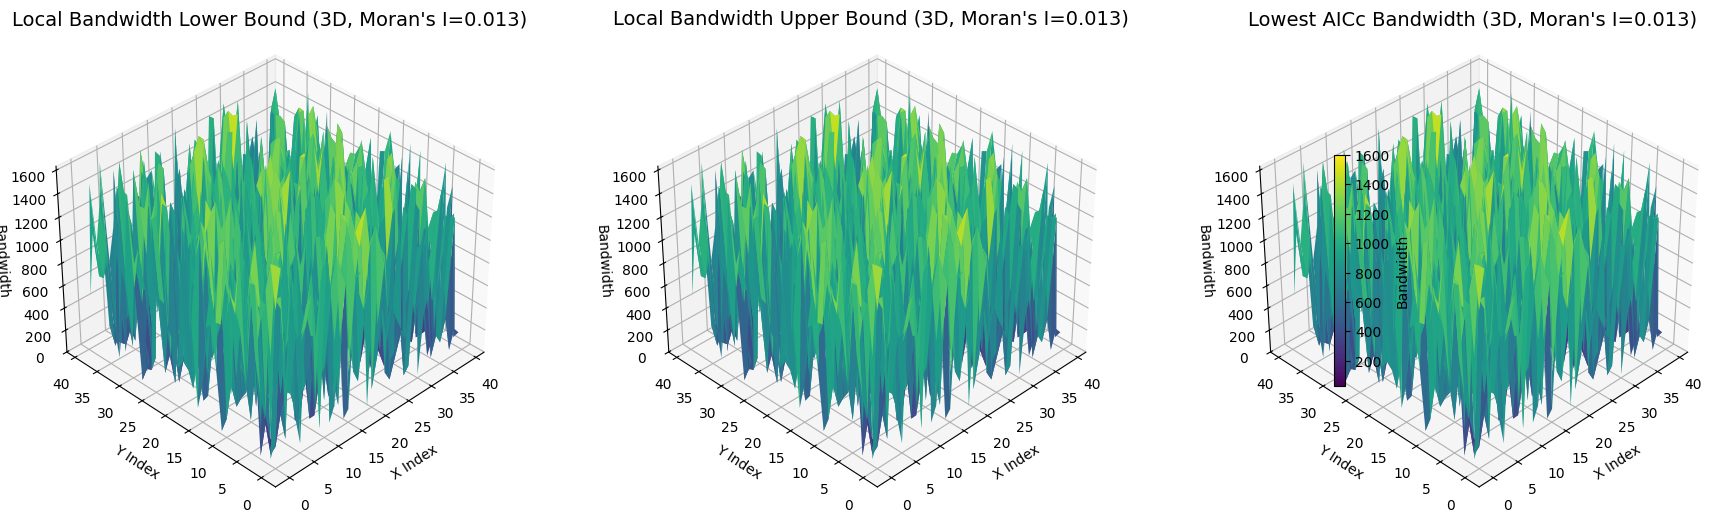

In [8]:
plot_surface_3d([lower_2d, upper_2d, lowest_aicc_bandwidth_2d],
    sub_title=[f"Local Bandwidth Lower Bound (3D, Moran's I={morans_values[0]:.3f})",
               f"Local Bandwidth Upper Bound (3D, Moran's I={morans_values[1]:.3f})",
               f"Lowest AICc Bandwidth (3D, Moran's I={morans_values[2]:.3f})"],
    size=size, vmin=global_vmin, vmax=global_vmax)